<a href="https://colab.research.google.com/github/sbenjam3/ST554_HW8/blob/main/ST554_HW8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ST 554 Homework 8 : Siona Benjamin

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, log_loss, accuracy_score
from sklearn.linear_model import LinearRegression, LassoCV, Lasso, Ridge, RidgeCV, ElasticNet, ElasticNetCV, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import make_pipeline

In this homework, we will build upon the work we did in Homework 7. In addition to the model we created originally, we will train regression/classification trees and random forest models, and compare their performance.

## Reading in Data

In this step, we read in the csv files for each dataset and then create a new column for each that defines whether the wine is white or red. We then use `pd.concat()` to combine the datasets into a continuous DataFrame. To get a quick overview of the data we can group it by the wine color and get the mean of all the columns.

In [ ]:
#read in csv of datasets
red_wines = pd.read_csv("winequality-red.csv", sep = ';')
white_wines = pd.read_csv("winequality-white.csv", sep = ';')

#create column for wine color
red_wines['color'] = 'red'
white_wines['color'] = 'white'

#concatenate red and white wine datasets
wine_quality_df = pd.concat([red_wines, white_wines], ignore_index=True)

#print out means of the total dataset
wine_quality_df.groupby('color').mean()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
color,,,,,,,,,,,,
red,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
white,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909


To be able to use the color of the wine as a predictive variable for our numerical models, we can use OneHotEncoding to encode the type of wine. We create two new categories in the process, `color_red` and `color_white`, where 1.0 indicates true and 0.0 indicates false.

In [ ]:
#create the encoder
encoder = OneHotEncoder(sparse_output=False)
#transform the color column into codes
color_encoded = encoder.fit_transform(wine_quality_df[['color']])
#get the features for the new columns
encoded_column_names = encoder.get_feature_names_out(['color'])
#create DataFrame from the encoded array
color_df = pd.DataFrame(color_encoded, columns=encoded_column_names, index=wine_quality_df.index)
#drop color column from original DataFrame and add the encoded columns
wine_quality_df = pd.concat([wine_quality_df.drop('color', axis=1), color_df], axis=1)

wine_quality_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color_red,color_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1.0,0.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1.0,0.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1.0,0.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1.0,0.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1.0,0.0


## Splitting Data

Now we can split the data into our x variables, or predictive variables, and our y variable or response variable.

In [ ]:
#set X values as predictive variables
X = wine_quality_df
#set y values as response variable of alcohol
y = wine_quality_df['alcohol']

We then split the predictors and response variable into training and testing datasets in a 70:30 ratio using `train_test_split`. With our data now split into training and testing sets, we can begin training our models.

In [ ]:
#split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

## Multiple Linear Regression Models

Now we can begin training some models starting off with multiple linear regression or MLR. To being, we use seaborn to create a pair plot. This lets us looks at the relationship between each of the predictive variables and lets us know whether we need to account for any interactions between them.

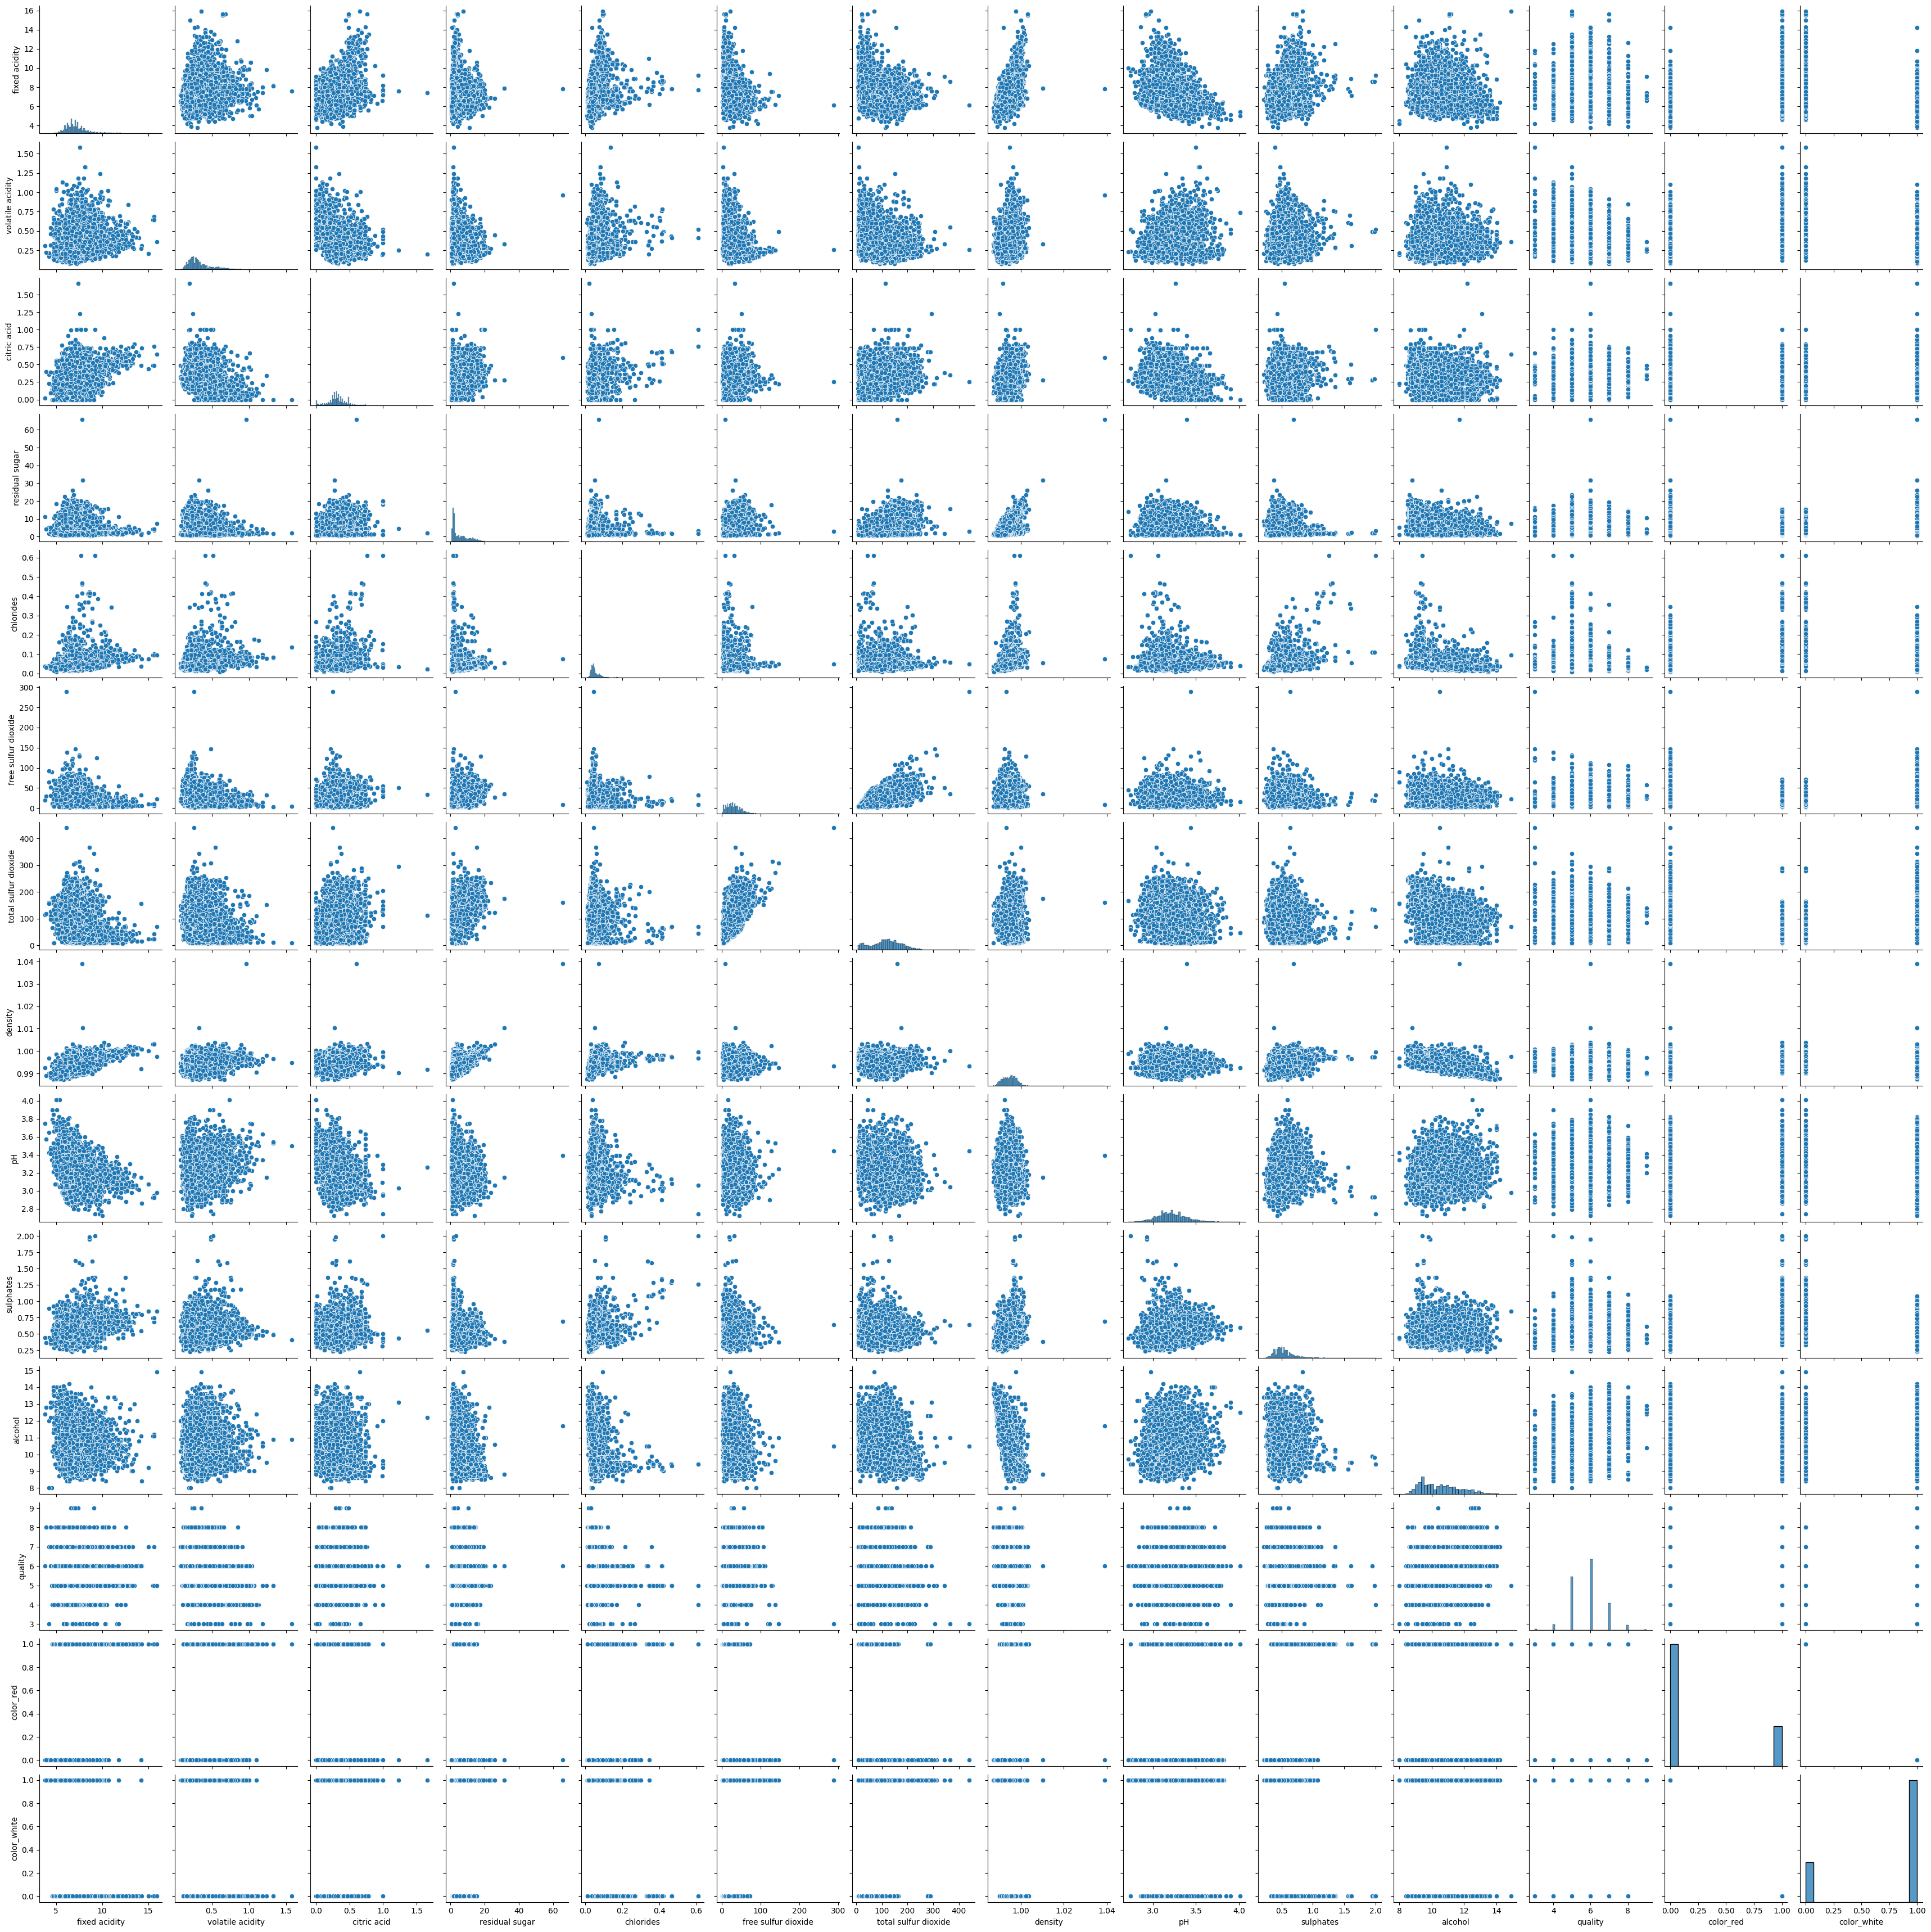

In [ ]:
#create pair plots for predictive variables
sns.pairplot(X)

Before training our MLR models, we make two seprate interaction terms that help to capture some of the relationships between our independent varibles. In the pair-wise plots above, it appears that there may be a slight interaction between density and fixed acidity, as well as free sulfur dioxide and total sulfure dioxide.

Along with interaction terms, we create a polynomial term with a factor of 2 to include in one of our MLR models.

In [ ]:
#create interaction term between density and fixed acidity
X["density_fixed_acidity_interaction"] = X["density"] * X["fixed acidity"]

#create interaction term between free sulfur dioxide and total sulfur dioxide
X["fsd_tsd_interaction"] = X["free sulfur dioxide"] * X["total sulfur dioxide"]

X.head()

#create polynomial feature
polynomial_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())


To account for the interaction terms, we'll run the `test_train_split` again.

In [ ]:
#resplit training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

First, we create a model named `full_model ` that is trained on all of the predicting variables expect for the interaction terms we created above. Our second model, `mlr_1` is trained on all of the predicting variables including the interaction terms. The model `mlr_2` includes the polynomial term we created above along with all the predicting variables and interaction terms. Lastly, `mlr_4` uses a small subset of the predicting variables.

In [ ]:
#model 1 - using all of the predictors without interaction terms
full_model = cross_validate(
    LinearRegression(),
    X_train.drop(["density_fixed_acidity_interaction","fsd_tsd_interaction"], axis=1),
    y_train,
    cv=5,
    scoring= "neg_mean_squared_error"
)
#model 2 - using all of the predictors including both interaction terms
mlr_1 = cross_validate(
    LinearRegression(),
    X_train,
    y_train,
    cv=5,
    scoring= "neg_mean_squared_error"
)
#model 3 - using all of the predictors with interaction terms and polynomial terms
mlr_2 = cross_validate(
    polynomial_model,
    X_train,
    y_train,
    cv=5,
    scoring= "neg_mean_squared_error"
)
#model 4 - using a subset of the predictors
mlr_3 = cross_validate(
    LinearRegression(),
    X_train[["pH", "sulphates"]],
    y_train,
    cv=5,
    scoring= "neg_mean_squared_error"
)

Below we can see the RMSE of each model after cross-validation. `mlr_1` which included the interaction terms shows a slightly lower RMSE than the model without the interactions terms. Adding a polynomial term ended up increasing the RMSE indicating that there may not be a second degree polynomial relationship within the data. The model with only two preditive variables ended up having the highest RMSE, which indicates that including more variables in the model is beneficial to performance.

In [ ]:
#extract test scores from each cross validation test
print(np.sqrt(-sum(full_model['test_score'])),
      np.sqrt(-sum(mlr_1['test_score'])),
      np.sqrt(-sum(mlr_2['test_score'])),
      np.sqrt(-sum(mlr_3['test_score'])))

2.8345468332466396e-14 9.438698818042786e-14 9.381422478679518e-05 2.648397081832962


Having used cross validation to uncover an ideal combination of predictive parameters, we can train our final model named `mlr`.

In [ ]:
#train final MLR model
mlr = LinearRegression().fit(X_train, y_train)

## LASSO Models

Now we'll move on to fitting LASSO models. LASSO stands for Least Angle Subset and Selection Operator. This model places a penalty on the sum of the absolute values of the regression coefficients. First, we'll use `LassoCV` to determine which alpha value is ideal for our model. For this model, we'll use all of our predictive variables.

In [ ]:
#use LassoCV to use cross validation with 5 predicting variables
lasso_mod = LassoCV(cv=5, random_state=0, alphas=np.linspace(0,2,100)).fit(X_train, y_train)
#complie alphas and MSE values for each k-fold
pd.DataFrame(zip(lasso_mod.alphas, lasso_mod.mse_path_), columns = ["alpha_value","MSE_by_fold"])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 r

,alpha_value,MSE_by_fold
0,0.000000,"[1.2386913336237202, 1.4344714840692705, 1.259..."
1,0.020202,"[1.238723804106889, 1.4339222645170804, 1.2597..."
2,0.040404,"[1.2387583320441027, 1.4333655950969533, 1.259..."
3,0.060606,"[1.23879342127159, 1.4328127753013122, 1.25965..."
4,0.080808,"[1.2388290421253205, 1.432260395388752, 1.2595..."
...,...,...
95,1.919192,"[0.0044889803708956875, 0.005517661551009503, ..."
96,1.939394,"[0.0025251447904076105, 0.003131001536282051, ..."
97,1.959596,"[0.0011221761819088948, 0.0013741820411391635,..."
98,1.979798,"[0.00028049133519960696, 0.0003499807391566400..."


Once we've used cross-validation to test a variety of alpha values, we can compile the alpha values and the averages of the MSE values from each k-fold. Doing so, we find that an alpha value of 0 produces the lowest average MSE of 8.5x10^-11.

In [ ]:
#compile alpha values and averages of MSE
fit_info = np.array(list(zip(lasso_mod.alphas_, np.mean(lasso_mod.mse_path_, axis=1))))
#sort fit_info list by average MSE
fit_info[fit_info[:,0].argsort()]

array([[0.00000000e+00, 8.26354971e-11],
       [2.02020202e-02, 3.14061928e-04],
       [4.04040404e-02, 1.25285674e-03],
       [6.06060606e-02, 2.82696013e-03],
       [8.08080808e-02, 5.01835276e-03],
       [1.01010101e-01, 7.83484053e-03],
       [1.21212121e-01, 1.13052972e-02],
       [1.41414141e-01, 1.53756958e-02],
       [1.61616162e-01, 2.00688603e-02],
       [1.81818182e-01, 2.53894112e-02],
       [2.02020202e-01, 3.13832326e-02],
       [2.22222222e-01, 3.79574226e-02],
       [2.42424242e-01, 4.51535014e-02],
       [2.62626263e-01, 5.29786205e-02],
       [2.82828283e-01, 6.14967670e-02],
       [3.03030303e-01, 7.05794092e-02],
       [3.23232323e-01, 8.02783189e-02],
       [3.43434343e-01, 9.06082806e-02],
       [3.63636364e-01, 1.01648952e-01],
       [3.83838384e-01, 1.13230649e-01],
       [4.04040404e-01, 1.25432252e-01],
       [4.24242424e-01, 1.38266640e-01],
       [4.44444444e-01, 1.51830352e-01],
       [4.64646465e-01, 1.65915732e-01],
       [4.848484

Now, we can use the ideal alpha value and use `Lasso` to train the model and extract the intercept and coefficients for each predicting variable.

In [ ]:
#fit model using optimal alpha
lasso_best = Lasso(lasso_mod.alpha_)
lasso_best.fit(X_train, y_train)
print(lasso_best.intercept_, lasso_best.coef_)

0.7637520853940494 [-9.47008537e-02 -2.93696560e-04 -3.12252129e-04  3.64991382e-05
 -1.14696595e-04 -2.74823422e-06  1.35231721e-06 -7.65322777e-01
 -7.05619155e-05 -6.16072317e-05  9.99864876e-01 -3.18696825e-05
  3.46756409e-04 -2.77380370e-16  9.50728001e-02  1.37912125e-09]


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(


## Ridge Regression Models

Next, we'll create models using ridge regression. As in the previous section, we'll use `RidgeCV` to use cross validation to search for an ideal alpha variable for our model. We will also use all of the predictive variables for this model.

In [ ]:
#run ridgeCV to find ideal alpha value
ridge_cv = RidgeCV(alphas=np.linspace(0,2,100), cv=5).fit(X_train, y_train)
ridge_cv.alpha_

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.68361e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.11598e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.4986e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


np.float64(0.0)

Runnin `RidgeCV` shows us that the ideal alpha for our model is still 0. We can incorporate this into our final ridge model.

In [ ]:
#train final ridge model with ideal alpha value
ridge = Ridge(alpha=ridge_cv.alpha_)
ridge.fit(X_train, y_train)

Ridge(alpha=np.float64(0.0))

## Elastic Net Models

Lastly, we'll make models with Elastic Net. This model has an l1 ratio and an alpha value used during training. We'll use cross validation here as well through `ElasticNetCV` to find ideal values for the l1 ratio and alpha. Again, we use all of the predictive variables for this model.

In [ ]:
#use elastic net cv to find ideal l1 ratio and alpha values
elastic_net_cv = ElasticNetCV(l1_ratio = [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1], alphas=np.linspace(0,2,100), cv=5).fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 r

In [ ]:
#print the alpha and l1 ratio
print(elastic_net_cv.alpha_)
print(elastic_net_cv.l1_ratio_)

0.0
0.1


Using `ElasticNetCV` we find that the ideal alpha is 0 as seen with the other models, and that the ideal l1 ratio is 0.1. We can then incorporate these values into our final elastic net model as seen below.

In [ ]:
#train final elastic net model with ideal alpha and l1 ratio
elastic_net = ElasticNet(alpha=elastic_net_cv.alpha_, l1_ratio=elastic_net_cv.l1_ratio_)
elastic_net.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(


ElasticNet(alpha=np.float64(0.0), l1_ratio=np.float64(0.1))

## Regression Tree Models

As our addition in Homework 8, we will fit a regression tree model to predit the alcohol variable as a response to the other variables in the dataset. To make a relationship between the models previously trained, we'll also use all of the predictive parameters in the dataset. First, we'll use cross validation to determine the optimal values for max_depth and min_samples_leaf. Max depth indicates the maximum level of splits within the tree and the minimum samples leaf indicates the minimum amount of training samples needed for a leaf node. From the grid search, we find that the ideal max_depth is 11 and the ideal min_samples_leaf is 3.

In [ ]:
#set up parameters for GridSearchCV
parameters = {'max_depth' : range(2,15),
              'min_samples_leaf': [3,5,10,50,100]}
#create grid search
model = GridSearchCV(DecisionTreeRegressor(), parameters, cv=5, scoring='neg_mean_squared_error')
#fit the model
model.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': range(2, 15),
                         'min_samples_leaf': [3, 5, 10, 50, 100]},
             scoring='neg_mean_squared_error')

In [ ]:
#print optimal max_depth and min_samples_leaf values
print(model.best_estimator_)

DecisionTreeRegressor(max_depth=8, min_samples_leaf=3)


Now that we know our ideal hyperparameters we can train a final model using these values.

In [ ]:
dtree = DecisionTreeRegressor(max_depth=11, min_samples_leaf=3)
dtree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=11, min_samples_leaf=3)

## Random Forest Models
Our last model to train is a random forest model. As with the other examples, we'll use GridSearchCV to find the optimal seting for the hyperparameter max_features. This hyperparameter controls the number of features the model randomly selects for each node split while building trees. Again, we'll use all the predictive variables in the wine dataset to train this model. After running the cross validation, we see that the ideal setting for max_features is 3. We can use this to train our final model.


In [ ]:
#set parameters to test
parameters = {"max_features":range(1,4)}
#set up grid search
rf = GridSearchCV(RandomForestRegressor(), parameters, cv=5, scoring='neg_mean_squared_error')
#fit random forst model
rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_features': range(1, 4)},
             scoring='neg_mean_squared_error')

In [ ]:
#print out ideal max_features
print(rf.best_estimator_)

RandomForestRegressor(max_features=3)


In [ ]:
rf_model = RandomForestRegressor(max_features=3)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_features=3)

## Testing Models

Now that we've used cross validation to select the best models for each type of regression, we can predict y-values of the test set with each one. To get a better idea of their predictions we can plot the predicted values against the true values. The linear trend shown by the plot shows that each model has decent predictive power for the alcohol variable. Visually, it seems like the Regression Tree model has comprable performance to the previously created models, whereas the Random Forest model seems to have worse performance.

In [ ]:
#predicting y values with best MLR model
y_pred_mlr = mlr.predict(X_test)
#predicting y values with LASSO model
y_pred_lasso = lasso_best.predict(X_test)
#predicting y values with Ridge Regression model
y_pred_ridge = ridge.predict(X_test)
#predicting y values with Elastic Net model
y_pred_elastic = elastic_net.predict(X_test)
#predicting y values with Regression Tree model
y_pred_dtree = dtree.predict(X_test)
#predicting y values with Random Forest model
y_pred_rf = rf_model.predict(X_test)

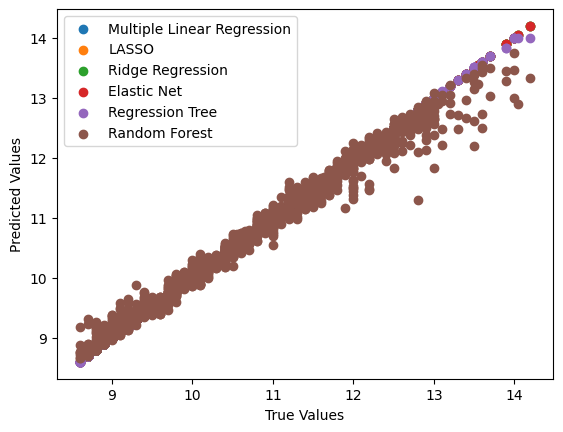

In [ ]:
#plot predicted values
plt.scatter(x=y_test, y=y_pred_mlr, label = 'Multiple Linear Regression')
plt.scatter(x=y_test, y=y_pred_lasso, label = 'LASSO')
plt.scatter(x=y_test, y=y_pred_ridge, label = 'Ridge Regression')
plt.scatter(x=y_test, y=y_pred_elastic, label = 'Elastic Net')
plt.scatter(x=y_test, y=y_pred_dtree, label = 'Regression Tree')
plt.scatter(x=y_test, y=y_pred_rf, label = 'Random Forest')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.legend()

Along with plotting the predicted values against the true values, we can also sklearn to calculate the mean absolute error (MAE) and the root mean squared error (RMSE) of each model. Doing so shows us that the MLR trained on all predictive variables has a similar MAE and RMSE to the ridge regression model trained on all predictive variables. The same can be said when comparing the LASSO and elastic net models. The MLR and Ridge models however perform much better and have lower errors than the other models tested. With the addition of the Regression Tree and Random Forest models, we can see that they have slightly worse performance than the LASSO and Elastic Net models and much worse performance than the MLR and Ridge models based off their MAE and RMSE values.

In [ ]:
#MAE
print("Mean Absolute Errors (MAE)")
print(f"MLR: {mean_absolute_error(y_test, y_pred_mlr)}")
print(f"LASSO: {mean_absolute_error(y_test, y_pred_lasso)}")
print(f"Ridge: {mean_absolute_error(y_test, y_pred_ridge)}")
print(f"Elastic Net: {mean_absolute_error(y_test, y_pred_elastic)}")
print(f"Regression Tree: {mean_absolute_error(y_test, y_pred_dtree)}")
print(f"Random Forest: {mean_absolute_error(y_test, y_pred_rf)}")
print("\n")
#RMSE
print("Root Mean Squared Errors (RMSE)")
print(f"MLR: {root_mean_squared_error(y_test, y_pred_mlr)}")
print(f"LASSO: {root_mean_squared_error(y_test, y_pred_lasso)}")
print(f"Ridge: {root_mean_squared_error(y_test, y_pred_ridge)}")
print(f"Elastic Net: {root_mean_squared_error(y_test, y_pred_elastic)}")
print(f"Regression Tree: {root_mean_squared_error(y_test, y_pred_dtree)}")
print(f"Random Forest: {root_mean_squared_error(y_test, y_pred_rf)}")

Mean Absolute Errors (MAE)
MLR: 3.1815917421996484e-14
LASSO: 0.0002427253333916523
Ridge: 3.3320810498247365e-14
Elastic Net: 0.0002427253333916523
Regression Tree: 0.000896096866107003
Random Forest: 0.08853847863247861


Root Mean Squared Errors (RMSE)
MLR: 4.19868187789072e-14
LASSO: 0.0003510088195943135
Ridge: 4.4550766561122534e-14
Elastic Net: 0.0003510088195943135
Regression Tree: 0.006808977161843409
Random Forest: 0.1547136998281986


# Classification Task

Now, we'll explore Logistic Regression along with Classification Trees and Random Forest Classifiers to create models that can predict whether wine will be red or white based on the predictive categories. First, we need to redefine our x and y datasets so that the x dataset no longer includes the color of the wine and that the y dataset is the wine color. We can then use `train_test_split` to create the training and testing datasets for models. We'll also create our training and testing datasets in a 70:30 ratio. We also employ stratified sampling to make sure we have an equal amount of red and white wine records in the training and testing datasets.

In [ ]:
#re-import datasets
red_wines = pd.read_csv("winequality-red.csv", sep = ';')
white_wines = pd.read_csv("winequality-white.csv", sep = ';')

#create color columns
red_wines['color'] = 'red'
white_wines['color'] = 'white'

#concatenate datasets
wine_quality_df = pd.concat([red_wines, white_wines], ignore_index=True)
wine_quality_df.groupby('color').mean()

#set X and y variables
X = wine_quality_df
y = wine_quality_df['alcohol']

In [ ]:
#define x and y variables
X = wine_quality_df.drop('color', axis=1)
y = wine_quality_df['color']

#split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,stratify=y)

## Logistic Regression


Using cross validation with the Logistic Regression model, we can test different combinations of predictive parameters to see which ones will do the best at the classification task while using negative log loss as the metric.

In [ ]:
#create model with all predictive variables
full_model = cross_validate(
    LogisticRegression(),
    X_train,
    y_train,
    cv=5,
    scoring= "neg_log_loss"
)
#create model with 5 predictive variables
lr_model2 = cross_validate(
    LogisticRegression(),
    X_train[["pH","sulphates","residual sugar","chlorides","citric acid"]],
    y_train,
    cv=5,
    scoring= "neg_log_loss"
)
#create model with 4 predictive variables
lr_model3 = cross_validate(
    LogisticRegression(),
    X_train[["pH","sulphates","residual sugar","chlorides"]],
    y_train,
    cv=5,
    scoring= "neg_log_loss"
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

By using the negative log loss as our metric, we can see that the model that used all of the predictive parameters while training had the best performance. We can then use the same dataset to train our final model.

In [ ]:
#extract test scores of all models
print(-sum(full_model['test_score']))
print(-sum(lr_model2['test_score']))
print(-sum(lr_model3['test_score']))

0.36096409111124317
1.4397210062689965
1.4800927975903062


In [ ]:
#train final model based off all predictive parameters
full_model = LogisticRegression().fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Classification Tree Model
In addition to the Logistic Regression model made as part of Homework 7, we'll create a Classification Tree to predict the color of wine. Similar to the previous section, we'll employ GridSearchCV to find ideal values for max_depth and min_samples_leaf. With cross validation, we find that the ideal max_depth is 3 and the ideal min_samples_leaf is 50. We then use these to train a final model.

In [ ]:
#set parameters for max_depth and min_samples_leaf
parameters = {'max_depth' : range(2,15),
              'min_samples_leaf': [ 5,10,50,100]}
ctm = GridSearchCV(DecisionTreeClassifier(), parameters, cv=5, scoring='neg_log_loss')
ctm.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': range(2, 15),
                         'min_samples_leaf': [5, 10, 50, 100]},
             scoring='neg_log_loss')

In [ ]:
print(ctm.best_estimator_)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=50)


In [ ]:
ctm_model = DecisionTreeClassifier(max_depth=3, min_samples_leaf=50)
ctm_model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=50)

## Random Forest
Next, we train a Random Forest model with classification trees. We repeat the cross validation step as well to find the ideal values for max_features. Like the previous two classification models, we'll train the Random Forest model with all of the predictive variables. With the cross validation step, we find that the ideal max features is 3, which we'll use in the final Random Forest classifier.


In [ ]:
#set values for max_features
parameters = {"max_features":range(1,4)}
#set up grid search
rfc = GridSearchCV(RandomForestClassifier(), parameters, cv=5, scoring='neg_log_loss')
#fit random forst model
rfc.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_features': range(1, 4)}, scoring='neg_log_loss')

In [ ]:
#print ideal max_features
print(rfc.best_estimator_)

RandomForestClassifier(max_features=3)


In [ ]:
frc_model = RandomForestClassifier(max_features=3)
frc_model.fit(X_train, y_train)

RandomForestClassifier(max_features=3)

## Model Testing

To calclate the log loss and accuracy score for the logistic regression, classification tree, and random forest classifier models, we have to predict the classes of our test set, along with the predicted probabilities for the test set. The predicted probabilities will be used to calculate the log loss. Comparing the log loss values and accuracy scores for each of the models shows that the Random Forest model had the greatest predictive success of wine color with a log loss of 0.07 and accuracy of 0.99. The Classification Tree was the lowest performing model with Logistic Regression landing in the middle of the three.

In [ ]:
#calculate predicted values
y_pred_log_reg = full_model.predict(X_test)
y_pred_dtree = ctm_model.predict(X_test)
y_pred_rf = frc_model.predict(X_test)
#calculate predicted probabilities
y_prob_log_reg = full_model.predict_proba(X_test)
y_prob_dtree = ctm_model.predict_proba(X_test)
y_prob_rf = frc_model.predict_proba(X_test)

In [ ]:
#Log Loss
print("Log-Loss")
print(f"Logistic Regression: {log_loss(y_test, y_prob_log_reg)}")
print(f"Classification Tree: {log_loss(y_test, y_prob_dtree)}")
print(f"Random Forest: {log_loss(y_test, y_prob_rf)}")
print("\n")
#Accuracy
print("Accuracy")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_log_reg)}")
print(f"Classification Tree: {accuracy_score(y_test, y_pred_dtree)}")
print(f"Random Forest: {accuracy_score(y_test, y_pred_rf)}")

Log-Loss
Logistic Regression: 0.07227748181137586
Classification Tree: 0.10846020385825968
Random Forest: 0.06520418473840109


Accuracy
Accuracy Score: 0.9825641025641025
Classification Tree: 0.9738461538461538
Random Forest: 0.9938461538461538
